In [42]:
import pandas as pd
import joblib
import json

print("=== 1. Cargando Datos y Configuraciones ===")

# Recuperamos los DataFrames segmentados y procesados
X_train = pd.read_pickle('data_processed/X_train.pkl')
X_test  = pd.read_pickle('data_processed/X_test.pkl')
y_train = pd.read_pickle('data_processed/y_train.pkl')
y_test  = pd.read_pickle('data_processed/y_test.pkl')
X_train_st = pd.read_pickle('data_processed/X_train_st.pkl')
y_train_st = pd.read_pickle('data_processed/y_train_st.pkl')

# Recuperamos el escalador 
scaler = joblib.load('data_processed/robust_scaler.pkl')

# Extraemos el peso desde el archivo JSON
with open('data_processed/config_pesos_xgboost.json', 'r') as archivo:
    config = json.load(archivo)

xgboost_weights = config["scale_pos_weight"]

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Fraudes en y_train: {y_train.sum()}")
print(f"Tamaño de X_train_smotetomek: {X_train_st.shape}")
print(f"Fraudes en y_train_smotetomek: {y_train_st.sum()}")
print(f"-> Peso matemático recuperado: {xgboost_weights:.2f}")

=== 1. Cargando Datos y Configuraciones ===
Tamaño de X_train: (227845, 30)
Fraudes en y_train: 394
Tamaño de X_train_smotetomek: (250196, 30)
Fraudes en y_train_smotetomek: 22745
-> Peso matemático recuperado: 577.29


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score
RANDOM_STATE = 42
# Entrenamos con los datos balanceados (X_train_st)
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_base.fit(X_train_st, y_train_st)

# Predecimos sobre el test set VIRGEN (X_test)
y_pred_lr = lr_base.predict(X_test)
y_proba_lr = lr_base.predict_proba(X_test)[:, 1]

# Métrica Reina: Área bajo la curva Precision-Recall
auprc_lr = average_precision_score(y_test, y_proba_lr)

print(f"\n-> AUPRC (Baseline LR): {auprc_lr:.4f}\n")
print("Reporte de Clasificación (Baseline LR):")
print(classification_report(y_test, y_pred_lr, target_names=['Legítima', 'Fraude']))


-> AUPRC (Baseline LR): 0.7518

Reporte de Clasificación (Baseline LR):
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.35      0.89      0.50        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [44]:
print("=== Entrenamiento de Baseline (LR + Class Weights) ===")

# Entrenamos con los datos ORIGINALES (X_train) y activamos el peso automático
lr_pesos = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_pesos.fit(X_train, y_train)

# Predecimos sobre el test set original (X_test)
y_pred_lr_pesos = lr_pesos.predict(X_test)
y_proba_lr_pesos = lr_pesos.predict_proba(X_test)[:, 1]

# Métrica Reina: Área bajo la curva Precision-Recall
auprc_lr_pesos = average_precision_score(y_test, y_proba_lr_pesos)

print(f"\n-> AUPRC (LR con Pesos): {auprc_lr_pesos:.4f}\n")
print("Reporte de Clasificación (LR con Pesos):")
print(classification_report(y_test, y_pred_lr_pesos, target_names=['Legítima', 'Fraude']))

=== Entrenamiento de Baseline (LR + Class Weights) ===

-> AUPRC (LR con Pesos): 0.7175

Reporte de Clasificación (LR con Pesos):
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [45]:
import xgboost as xgb
# Ahora ENTRENAMOS XGBOOST con weights
# --- Weights XGBoost ---
xgb_weights = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='aucpr',       # métrica interna alineada con nuestro objetivo
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=xgboost_weights
)
xgb_weights.fit(X_train, y_train)

y_proba_weights = xgb_weights.predict_proba(X_test)[:, 1]
y_pred_weights  = xgb_weights.predict(X_test)

auprc_weights = average_precision_score(y_test, y_proba_weights)

print(f"=== BASELINE XGBoost ===")
print(f"AUPRC: {auprc_weights:.4f}")
print(classification_report(y_test, y_pred_weights, target_names=['Legítima', 'Fraude']))

=== BASELINE XGBoost ===
AUPRC: 0.8652
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.78      0.84      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [46]:
# Ahora ENTRENAMOS XGBOOST con SMOTETOMEK
# --- ST XGBoost ---
xgb_ST = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='aucpr',       
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_ST.fit(X_train_st, y_train_st)

y_proba_ST = xgb_ST.predict_proba(X_test)[:, 1]
y_pred_ST  = xgb_ST.predict(X_test)

auprc_ST = average_precision_score(y_test, y_proba_ST)

print(f"=== ST XGBoost ===")
print(f"AUPRC: {auprc_ST:.4f}")
print(classification_report(y_test, y_pred_ST, target_names=['Legítima', 'Fraude']))

=== ST XGBoost ===
AUPRC: 0.8626
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.67      0.87      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\JPabl\AppData\Local\Temp\ipykernel_43380\591228479.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=modelos, y=auprc_scores, palette='magma')


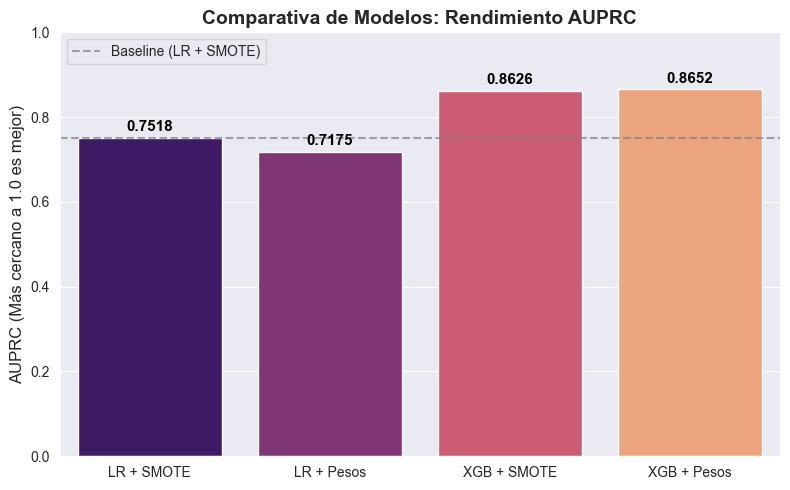

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Los valores de AUPRC calculados en las celdas anteriores
modelos = ['LR + SMOTE', 'LR + Pesos', 'XGB + SMOTE', 'XGB + Pesos']
auprc_scores = [auprc_lr, auprc_lr_pesos, auprc_ST, auprc_weights]

plt.figure(figsize=(8, 5))
# Usamos una paleta de colores magma
ax = sns.barplot(x=modelos, y=auprc_scores, palette='magma')

plt.title('Comparativa de Modelos: Rendimiento AUPRC', fontsize=14, fontweight='bold')
plt.ylabel('AUPRC (Más cercano a 1.0 es mejor)', fontsize=12)
plt.ylim(0, 1)  # El techo de la métrica es 1.0

# Añadimos los valores numéricos grandes encima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5), textcoords='offset points')

# Línea visual que representa dónde empezó tu proyecto (el Baseline a vencer)
plt.axhline(y=auprc_lr, color='gray', linestyle='--', alpha=0.7, label='Baseline (LR + SMOTE)')
plt.legend(loc='upper left')

plt.savefig('auprc_benchmark.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

C:\Users\JPabl\AppData\Local\Temp\ipykernel_43380\1221663634.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=modelos, y=f1_scores, palette='viridis')


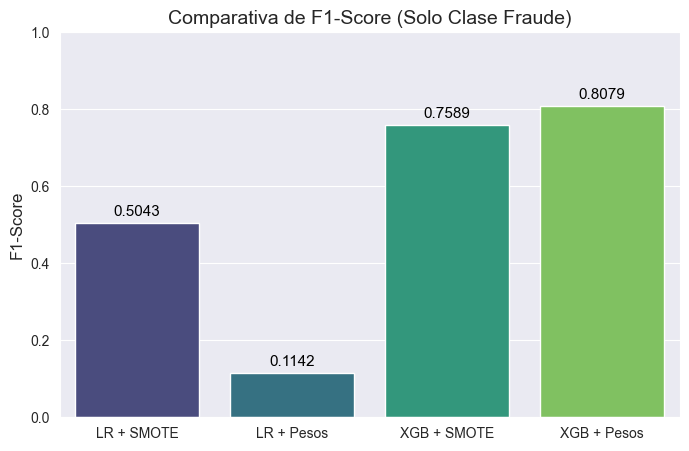

In [48]:
from sklearn.metrics import f1_score
import seaborn as sns

# Calculamos el F1-Score exclusivamente para la clase 1 (pos_label=1)
f1_lr = f1_score(y_test, y_pred_lr)
f1_lr_pesos = f1_score(y_test, y_pred_lr_pesos)
f1_xgb_st = f1_score(y_test, y_pred_ST)
f1_xgb_weights = f1_score(y_test, y_pred_weights)

modelos = ['LR + SMOTE', 'LR + Pesos', 'XGB + SMOTE', 'XGB + Pesos']
f1_scores = [f1_lr, f1_lr_pesos, f1_xgb_st, f1_xgb_weights]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=modelos, y=f1_scores, palette='viridis')
plt.title('Comparativa de F1-Score (Solo Clase Fraude)', fontsize=14)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1)  # El máximo teórico es 1.0

# Añadimos los valores numéricos encima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.savefig('f1_score_benchmark.png', dpi=150, bbox_inches='tight')

plt.show()